In [1]:
#import libraries
import numpy as np
from helper import *#import helper functions
import list as lt
%load_ext autoreload
%aimport helper, list  
%autoreload 1
np.random.seed(1)


from numpy import __config__ as cfg
import os

#print(cfg.show())  # Shows same info
os.environ["OPENBLAS_NUM_THREADS"] = "8"
print("OPENBLAS_NUM_THREADS =", os.environ.get("OPENBLAS_NUM_THREADS"))

OPENBLAS_NUM_THREADS = 8


In [2]:
header = load_header('../data/dataset/x_test.csv')
print(header)

['Id', '_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'EXERANY2', 'EXR

In [3]:

#col_list = lt.col_list  # Example: take first 10 columns to expand
#remove the column named '_MICHD'
col_list = [col for col in header[10:] if col != '_MICHD']
print(col_list)
x_train_expanded, expanded_col_names = expand_dataset_col(col_list, '../data/dataset/x_train.csv', False)
print(expanded_col_names)
print(x_train_expanded)
#print("x_train_expanded saved to x_train_expanded.csv")


['CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'EXERANY2', 'EXRACT11', 'EXEROFT1', 'EXERHMM1', 'EXRACT21', 'EXEROFT2', 'EXERHMM2', 'STRENGTH', 'LMTJOIN3',

In [4]:
#load x_train and y_train
x_train_full = x_train_expanded#load_data_column('x_train_expanded.csv', column_list=None)
y_train_full = load_data_col('../data/dataset/y_train.csv', cols=(1))

In [5]:

x_train,y_train,x_test,y_test = split_data_train_test_80(x_train_full, y_train_full, seed=1)


In [6]:
#SVM Classifier
from sklearn import svm
clf = svm.SVC(max_iter=100, kernel='linear', C=1.0, gamma='scale', decision_function_shape='ovo')
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("SVM Classifier Accuracy:", accuracy)
#ROC AUC
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred)
print("SVM Classifier ROC AUC:", roc_auc)
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_test, y_pred))


/home/nyx/Documents/EPFL/ML_course/.pixi/envs/default/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM Classifier Accuracy: 0.11013759580660398
SVM Classifier ROC AUC: 0.4984782735169606
Classification Report:
               precision    recall  f1-score   support

        -1.0       0.90      0.03      0.05     59774
         1.0       0.09      0.97      0.16      5853

    accuracy                           0.11     65627
   macro avg       0.50      0.50      0.11     65627
weighted avg       0.83      0.11      0.06     65627



In [7]:
# use xgboost to classify
import xgboost as xgb
model = xgb.XGBClassifier(n_estimators=2,scale_pos_weight=5.0,subsample=0.5, learning_rate=1, objective='binary:logistic')
#modify ytrain to be 0 and 1
y_train = np.where(y_train == -1, 0, y_train)
model.fit(x_train, y_train)
y_pred_xgb = model.predict(x_test)
#modify y_test to be -1 and 1
y_test = np.where(y_test == 0, -1, y_test)
#modify y_pred_xgb to be -1 and 1
y_pred_xgb = np.where(y_pred_xgb == 0, -1, y_pred_xgb)
#use sklearn accuracy_score and roc_auc_score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)
print("XGBoost Classifier ROC AUC:", roc_auc_xgb)
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
# --- IGNORE ---


ModuleNotFoundError: No module named 'xgboost'

In [8]:
import sklearn
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight={-1: 1.0, 1: 5.0}, max_iter=100,n_jobs=-1)
model.fit(x_train, y_train)
y_pred_sklearn = model.predict(x_test)
accuracy_sklearn = np.mean(y_pred_sklearn == y_test.flatten())
print(f"Sklearn Logistic Regression Accuracy: {accuracy_sklearn * 100:.2f}%")
f1_sklearn = f1_score(y_test.flatten(), y_pred_sklearn)
print(f"Sklearn F1 Score: {f1_sklearn:.4f}")


Sklearn Logistic Regression Accuracy: 85.65%
Sklearn F1 Score: 0.4338


/home/nyx/Documents/EPFL/ML_course/.pixi/envs/default/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


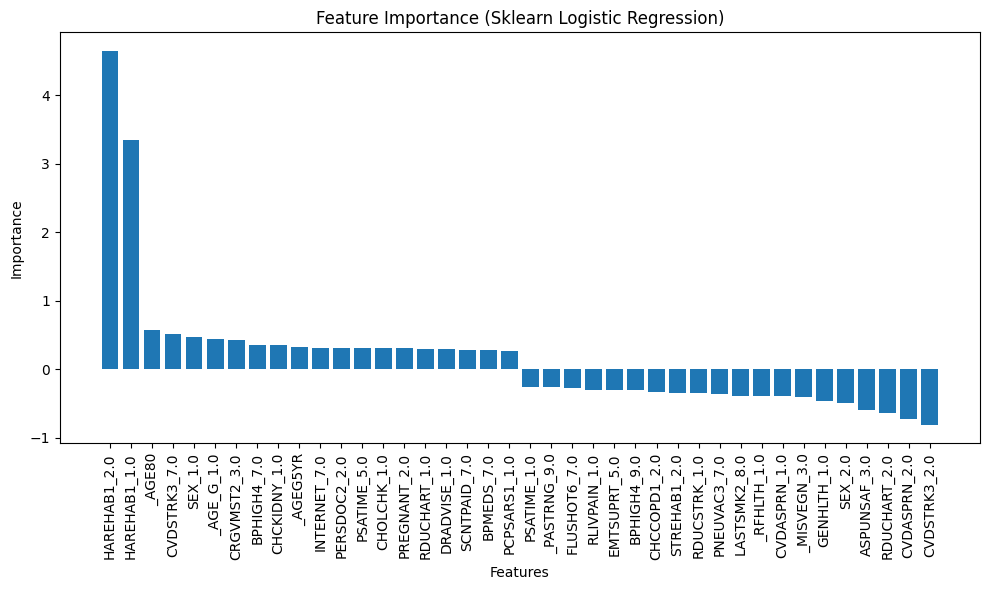

In [24]:
#create a graph showing the most important features only the first 10 and last 10 features
import matplotlib.pyplot as plt

feature_importance = (model.coef_[0])
feature_names = np.asarray(expanded_col_names)
sorted_indices = np.concatenate([np.argsort(feature_importance)[::-1][:20], np.argsort(feature_importance)[::-1][-20:]])

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_indices)), feature_importance[sorted_indices], align="center")
plt.xticks(range(len(sorted_indices)), feature_names[sorted_indices], rotation=90)
plt.title("Feature Importance (Sklearn Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

the shape of x_train is: (262508, 1101)
the shape of y_train is: (262508,)
the shape of x_test is: (65627, 1101)
the shape of y_test is: (65627,)
Iter 0: train_loss=0.6116, val_loss=0.0217
Iter 10: train_loss=0.1741, val_loss=-1.1158
Iter 20: train_loss=0.0819, val_loss=-1.7382
Iter 30: train_loss=-0.0688, val_loss=-2.5551
Iter 40: train_loss=-0.1401, val_loss=-3.0380
Iter 50: train_loss=-0.3829, val_loss=-3.9507
Iter 60: train_loss=-0.2772, val_loss=-4.1430
Iter 70: train_loss=-0.5471, val_loss=-4.8943
Iter 80: train_loss=-0.3067, val_loss=-5.0786
Iter 90: train_loss=-0.6802, val_loss=-5.9160
Iter 100: train_loss=-0.7603, val_loss=-6.3329
Iter 110: train_loss=-0.8358, val_loss=-6.9039
Iter 120: train_loss=-0.6428, val_loss=-7.2667
Iter 130: train_loss=-0.8930, val_loss=-7.6733
Iter 140: train_loss=-0.8940, val_loss=-8.0948
Iter 150: train_loss=-0.8110, val_loss=-8.4339
Iter 160: train_loss=-1.0352, val_loss=-8.9492
Iter 170: train_loss=-0.7871, val_loss=-9.2416
Iter 180: train_loss=-1

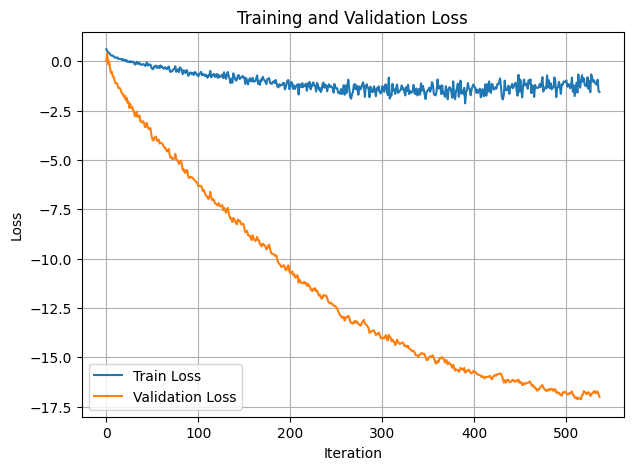

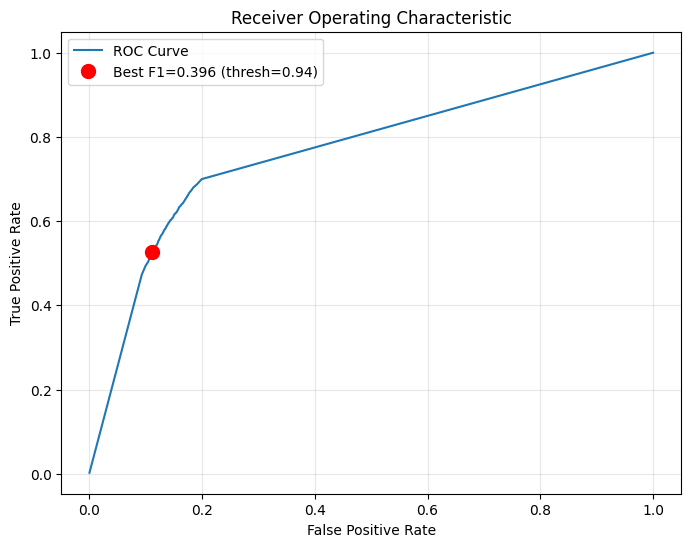

Best F1 Score: 0.3958 at threshold 0.94
TPR: 0.5267, FPR: 0.1111


(np.float64(0.3957892034148534), np.float64(0.9400000000000001))

In [40]:
%autoreload 1
model = LogisticRegression_costum(
    lr=0.1,
    max_iter=1000,
    penalty="l2",
    alpha=0.1,
    class_weight={-1: 1.0, 1: 30.0},
    bias_init=0.5,
    verbose=True,
    early_stopping=True,
    method='stochastic',
    patience=20,
    batch_size=10000
)
print("the shape of x_train is:", x_train.shape)
print("the shape of y_train is:", y_train.shape)
print("the shape of x_test is:", x_test.shape)
print("the shape of y_test is:", y_test.shape)

model.fit(x_train, y_train, x_test, y_test)
#model.evaluate(x_test, y_test)
#use sklearn to compute f1 score
model.roc_curve(x_test, y_test, plot=True)

In [12]:
y_pred = model.predict(x_test, threshold=0.5)
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy*100, "%")
print("F1 Score:", f1_score(y_test.flatten(), y_pred.flatten()))

Accuracy: 85.07016929007878 %
F1 Score: 0.39006474103585653


In [13]:
%autoreload 1
y_pred = model.predict(x_test, threshold=0.5)
print(y_pred[:20])

[ 1 -1  1 -1 -1 -1 -1 -1 -1  1 -1  1  1 -1 -1 -1 -1 -1 -1 -1]



Accuracy: 0.844

Class -1.0: precision=0.953, recall=0.872, f1=0.911, support=59787
Class 1.0: precision=0.300, recall=0.563, f1=0.391, support=5840

Macro avg:   precision=0.627, recall=0.717, f1=0.651
Weighted avg: precision=0.895, recall=0.844, f1=0.865


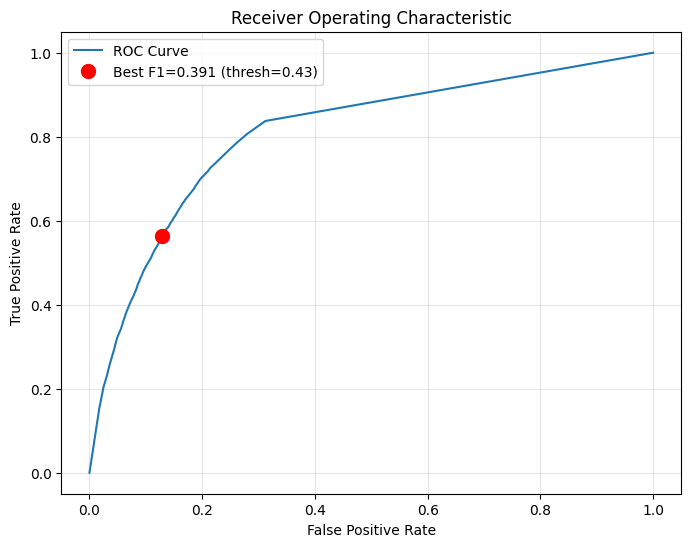

Best F1 Score: 0.3915 at threshold 0.43
TPR: 0.5628, FPR: 0.1282


(np.float64(0.391472637408444), np.float64(0.43))

In [15]:
%autoreload 1
model.evaluate(x_test, y_test, threshold=0.43)

model.roc_curve(x_test, y_test, plot=True)

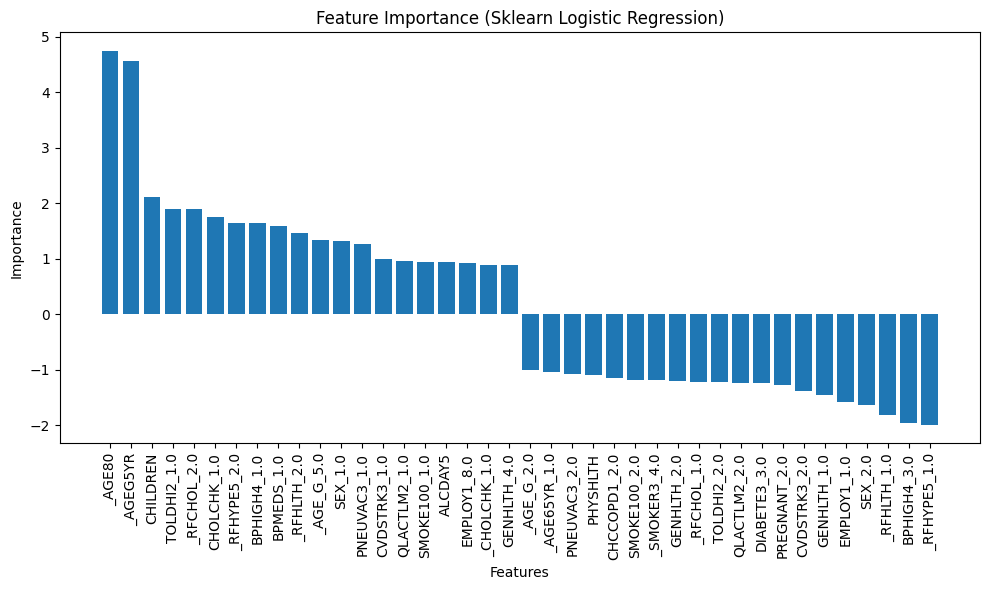

In [41]:
feature_importance = (model.weights_[1:])  # Exclude intercept
feature_names = np.asarray(expanded_col_names)
sorted_indices = np.concatenate([np.argsort(feature_importance)[::-1][:20], np.argsort(feature_importance)[::-1][-20:]])

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_indices)), feature_importance[sorted_indices], align="center")
plt.xticks(range(len(sorted_indices)), feature_names[sorted_indices], rotation=90)
plt.title("Feature Importance (Sklearn Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [17]:
y_test_pred_sklearn = np.where(y_pred_sklearn == 0, -1, 1)
print("Predictions from our model after modification:", y_pred_sklearn.flatten()[:100])
#calulate accuracy and f1 score for sklearn model
accuracy_sklearn = np.mean(y_pred_sklearn == y_test.flatten())
print(f"Sklearn Logistic Regression Accuracy: {accuracy_sklearn * 100:.2f}%")
#caluculate f1
f1_sklearn = f1_score(y_test.flatten(), y_pred_sklearn)
print(f"Sklearn F1 Score: {f1_sklearn:.4f}")

NameError: name 'y_pred_sklearn' is not defined

In [42]:
header = load_header('../data/dataset/x_train.csv')
print(header)
header_test = load_header('../data/dataset/x_test.csv')
print(header_test)
#check differences between header and header_test
for col in header:
    if col not in header_test:
        print(f"Column '{col}' is in train but not in test.")  

['Id', '_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'EXERANY2', 'EXR

In [43]:
#Create a csv submission file with the predictions on the test set

#x_test_sub = load_data_col('../data/dataset/x_test.csv', cols=col_index)
x_test_sub_exp, header_expanded_test = expand_dataset_col(col_list, '../data/dataset/x_test.csv' )
print(" header:", header_expanded_test)
print("start filling missing columns")
x_test_sub_exp_better = fill_missing_column(expanded_col_names, header_expanded_test, x_test_sub_exp)
print("end filling missing columns")

print("normal expansion"+str(x_test_sub_exp.shape))
print("better expansion"+str(x_test_sub_exp_better.shape))
y_pred_probabilities = model.predict_proba(X=x_test_sub_exp_better)
print("Predicted probabilities from our model:", y_pred_probabilities.flatten()[:100])
y_pred = model.predict(X=x_test_sub_exp_better, threshold=0.94)
print("Predictions from our model:", y_pred.flatten()[:100])

#calculate accuracy and f1 score for sklearn model on test submission set
#predict using the weights generated by our model
# prepare ids for submission: try loading an ID column, otherwise use 1..N
try:
    ids = load_data_col('../data/dataset/x_test.csv', cols=(0,), has_header=True).astype(int)
except Exception:
    ids = np.arange(1, x_test_sub_exp_better.shape[0] + 1)
create_csv_submission(ids, y_pred, "submission.csv")


Original col_list: ['CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'EXERANY2', 'EXRACT11', 'EXEROFT1', 'EXERHMM1', 'EXRACT21', 'EXEROFT2', 'EXERHMM2', 'STR

In [ ]:
x_test_sub_exp_better.shape